# Hotel Bookings EDA Project
## 1. Project Introduction
**Student name:** Kandikatla Nihal  
**Dataset:** Hotel Booking Demand (`hotel_bookings.csv`)  
**Kaggle link:** https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

This dataset contains hotel booking records, including hotel type, guest counts, arrival details, booking channels, cancellations, and room rates.

**Objective:** Clean the data and understand booking patterns, cancellations, lead time, and average daily rate (ADR). Lead time means days between booking and arrival. The CSV does not specify the currency of ADR.

**Colab instructions:** Upload `hotel_bookings.csv` using the Files panel on the left, then run the cells from top to bottom. The observations below are based on the supplied CSV. Understand each step and explain the findings in your own words before submission.

## 2. Load the Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


## 3. Understand the Dataset

In [ ]:
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())

Rows and columns: (119390, 32)
Column names: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

The loop below checks the unique values in every column. Long arrays may be shortened in the display, while `nunique()` above gives the number of distinct values.

In [ ]:
for column in df.columns:
    print("\nColumn:", column)
    print(df[column].unique())


Column: hotel
['Resort Hotel' 'City Hotel']

Column: is_canceled
[0 1]

Column: lead_time
[342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200 192
 361 207 174 330 134 350 334 283 

**Observation:** The original dataset has 119,390 rows and 32 columns. It includes text categories and numerical values. The two hotel categories are City Hotel and Resort Hotel. Agent and company numbers are identifiers, not quantities. Some columns contain missing values.

## 4. Check and Remove Duplicate Records
For this exercise, remove rows that are identical across all columns. There is no booking ID, so some identical rows could represent different real bookings. All later results describe the deduplicated records, and this decision can change booking counts and cancellation rates.

In [ ]:
print("Before:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
df_clean = df.drop_duplicates().copy()
print("After:", df_clean.shape)

Before: (119390, 32)
Duplicate rows: 31994
After: (87396, 32)


**Observation:** 31,994 identical rows are removed, leaving 87,396 rows.

## 5. Handle Missing Values
Use the median for missing children counts because it is less affected by extreme values than the mean. Use `Unknown` for missing countries and agent/company IDs because their real values cannot be inferred. Missing agent or company IDs do not prove that no agent or company was involved.

In [ ]:
df_clean.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [ ]:
df_clean["children"] = df_clean["children"].fillna(df_clean["children"].median())
df_clean["country"] = df_clean["country"].fillna("Unknown")

In [ ]:
df_clean["agent"] = df_clean["agent"].astype("Int64").astype("string")
df_clean["company"] = df_clean["company"].astype("Int64").astype("string")
df_clean["agent"] = df_clean["agent"].fillna("Unknown")
df_clean["company"] = df_clean["company"].fillna("Unknown")

In [ ]:
df_clean.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

**Observation:** Missing values in children, country, agent, and company are filled. Agent and company remain labels; they will not be included in numerical correlations.

## 6. Clean the Dataset
Convert children counts to integers and the status date to a date type. Remove extra spaces from text columns. Category inspection did not reveal spelling variants or unwanted symbols that require correction, so no arbitrary replacements are made. Keep all original columns because none must be deleted for this analysis.

In [ ]:
df_clean["children"] = df_clean["children"].astype(int)
df_clean["reservation_status_date"] = pd.to_datetime(df_clean["reservation_status_date"])

In [ ]:
text_columns = df_clean.select_dtypes(include=["object", "string"]).columns
for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

Check questionable records before deciding what to do with them. Keep negative ADR and zero-guest rows marked for review because their meaning cannot be confirmed from the CSV. `Undefined` categories are retained as recorded; they are not guessed or renamed.

In [ ]:
df_clean["adr_needs_review"] = df_clean["adr"] < 0
print("Negative ADR records:", df_clean["adr_needs_review"].sum())
print("Zero-guest records:", ((df_clean["adults"] + df_clean["children"] + df_clean["babies"]) == 0).sum())
print("Missing values:", df_clean.isnull().sum().sum())

Negative ADR records: 1
Zero-guest records: 166
Missing values: 0


**Observation:** One negative ADR value needs review. Keeping a review flag preserves the original information. Subsequent summaries retain this record, so ADR results should be interpreted with this limitation.

## 7. Analyze Categorical Columns

In [ ]:
for column in text_columns:
    print("\nColumn:", column)
    print(df_clean[column].value_counts())


Column: hotel
hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64

Column: arrival_date_month
arrival_date_month
August       11257
July         10057
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64

Column: meal
meal
BB           67978
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64

Column: country
country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 178, dtype: int64

Column: market_segment
market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

Column: dis

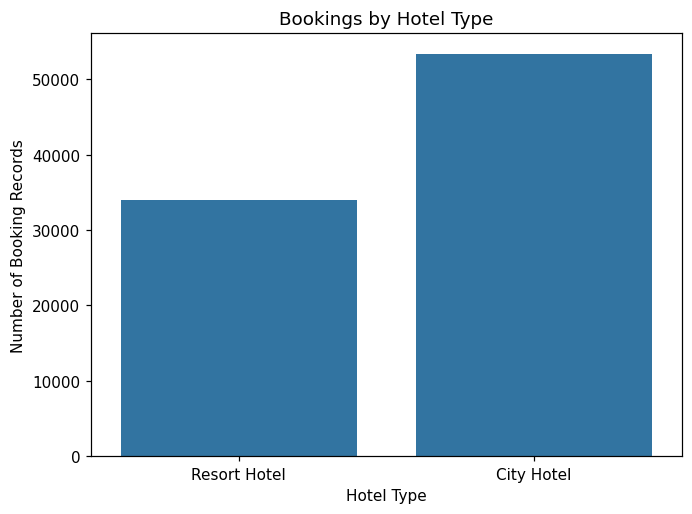

In [ ]:
sns.countplot(data=df_clean, x="hotel")
plt.title('Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Booking Records')
plt.tight_layout()
plt.show()

**Observation:** City Hotel has 53,428 records and Resort Hotel has 33,968. City Hotel contributes more observations, so overall results are influenced more by city bookings.

## 8. Analyze Numerical Columns

In [ ]:
numerical_columns = ["lead_time", "adr", "adults", "children", "babies", "stays_in_week_nights", "stays_in_weekend_nights"]
df_clean[numerical_columns].agg(["mean", "median", "min", "max", "std"])

,lead_time,adr,adults,children,babies,stays_in_week_nights,stays_in_weekend_nights
mean,79.891368,106.337246,1.875795,0.138633,0.010824,2.625395,1.005263
median,49.000000,98.100000,2.000000,0.000000,0.000000,2.000000,1.000000
min,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,0.000000
max,737.000000,5400.000000,55.000000,10.000000,10.000000,50.000000,19.000000
std,86.052325,55.013953,0.626500,0.455871,0.113597,2.053584,1.031921


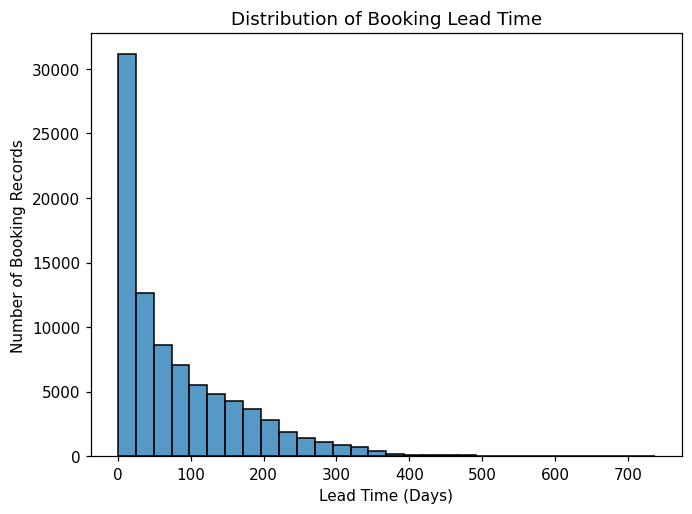

In [ ]:
sns.histplot(data=df_clean, x="lead_time", bins=30)
plt.title('Distribution of Booking Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Booking Records')
plt.tight_layout()
plt.show()

**Observation:** Mean lead time is 79.9 days, while the median is 49 days. A smaller group of early bookings raises the mean, so the median better represents a typical booking.

## 9. Detect and Handle Outliers
Use a box plot and the interquartile range (IQR). IQR is the difference between the 75th percentile (Q3) and the 25th percentile (Q1). Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are potential outliers.

High room rates can be genuine. Flag unusual ADR values instead of deleting or capping them without evidence. This keeps the analysis transparent.

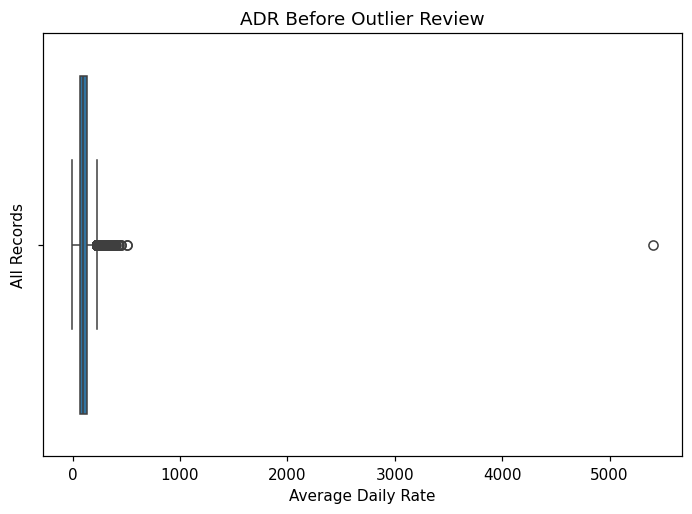

In [ ]:
sns.boxplot(data=df_clean, x="adr")
plt.title('ADR Before Outlier Review')
plt.xlabel('Average Daily Rate')
plt.ylabel('All Records')
plt.tight_layout()
plt.show()

In [ ]:
rows_before = len(df_clean)
Q1 = df_clean["adr"].quantile(0.25)
Q3 = df_clean["adr"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_clean["adr_outlier"] = (df_clean["adr"] < lower_limit) | (df_clean["adr"] > upper_limit)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Flagged records:", df_clean["adr_outlier"].sum())
print("Rows before review:", rows_before)
print("Rows after review:", len(df_clean))

Lower limit: -21.0
Upper limit: 227.0
Flagged records: 2490
Rows before review: 87396
Rows after review: 87396


**Observation:** The ADR limits are −21 and 227. Values outside these limits are flagged for review. No rows or ADR values are changed, so the before/after distribution is identical. The negative ADR also needs review even though it is inside these statistical limits. Statistical outliers and data errors are not always the same.

## 10. Perform Univariate Analysis
Univariate analysis studies one variable at a time. Hotel counts and the lead-time histogram above already cover category frequency and a numerical distribution. Here, examine cancellation status: 0 means not canceled and 1 means canceled.

In [ ]:
df_clean["is_canceled"].value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

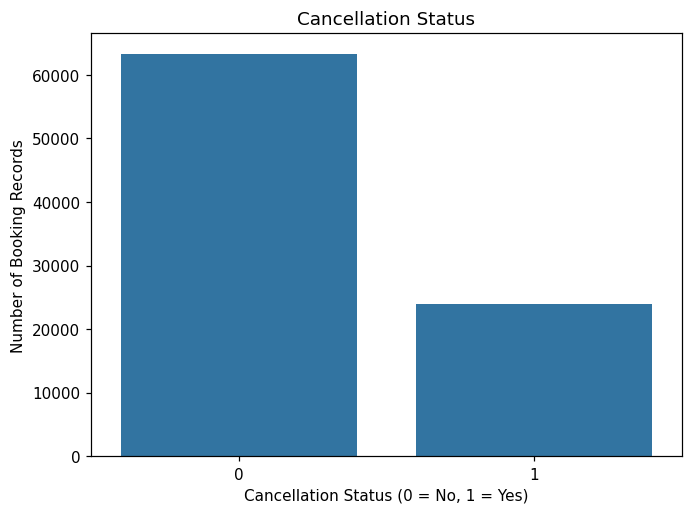

In [ ]:
sns.countplot(data=df_clean, x="is_canceled")
plt.title('Cancellation Status')
plt.xlabel('Cancellation Status (0 = No, 1 = Yes)')
plt.ylabel('Number of Booking Records')
plt.tight_layout()
plt.show()

**Observation:** 27.5% of deduplicated bookings were canceled. Cancellations are a substantial share of records, so booking volume alone does not represent completed stays.

## 11. Perform Bivariate Analysis
Bivariate analysis compares two variables. First compare hotel type with average daily rate.

In [ ]:
df_clean.groupby("hotel")["adr"].median()

hotel
City Hotel      105.3
Resort Hotel     79.5
Name: adr, dtype: float64

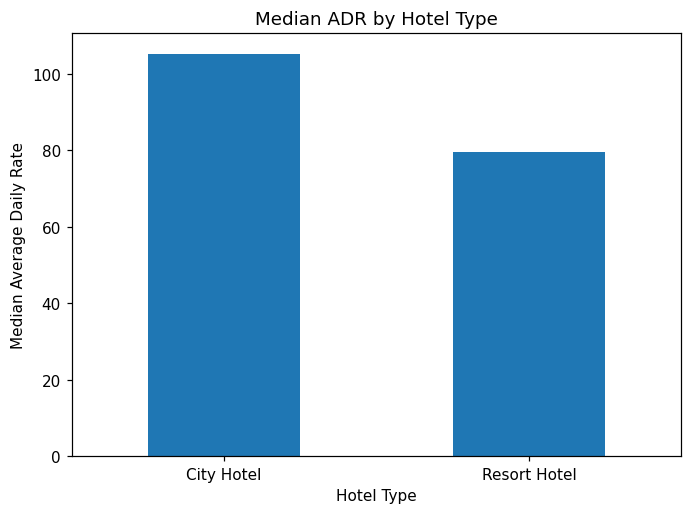

In [ ]:
df_clean.groupby("hotel")["adr"].median().plot(kind="bar", rot=0)
plt.title('Median ADR by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Median Average Daily Rate')
plt.tight_layout()
plt.show()

**Observation:** Median ADR is 105.3 for City Hotel and 79.5 for Resort Hotel. This indicates a difference in typical recorded prices, but does not prove that hotel type alone causes the difference.

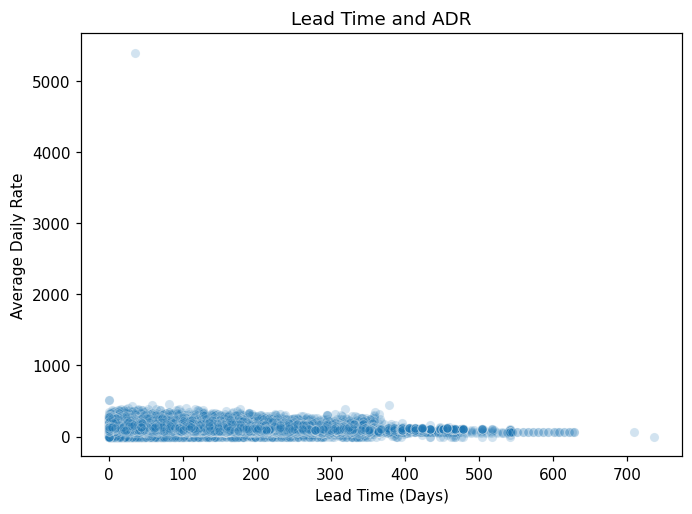

In [ ]:
sns.scatterplot(data=df_clean, x="lead_time", y="adr", alpha=0.2)
plt.title('Lead Time and ADR')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Average Daily Rate')
plt.tight_layout()
plt.show()

**Observation:** The very high ADR record stretches the vertical scale and makes the main cluster difficult to see. Use the numerical correlation below to support interpretation; this scatter plot alone cannot establish a strong relationship.

In [ ]:
df_clean[["lead_time", "adr"]].corr()

,lead_time,adr
lead_time,1.000000,0.023564
adr,0.023564,1.000000


In [ ]:
df_clean.groupby("hotel")["is_canceled"].mean() * 100

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64

**Observation:** Cancellation rates are 30.0% for City Hotel and 23.5% for Resort Hotel. Comparing percentages accounts for their different numbers of bookings.

In [ ]:
df_clean.groupby("is_canceled")["lead_time"].median()

is_canceled
0    38.0
1    80.0
Name: lead_time, dtype: float64

**Observation:** Canceled bookings have a median lead time of 80 days, compared with 38 days for bookings that were not canceled. Earlier bookings may face more opportunities for plans to change; this is an interpretation, not proof of causation.

## 12. Perform Multivariate Analysis
Multivariate analysis studies several variables together. Exclude identifiers from correlation because their numbers are labels.

In [ ]:
correlation_columns = ["is_canceled", "lead_time", "adr", "adults", "previous_cancellations", "total_of_special_requests"]
correlation = df_clean[correlation_columns].corr()
correlation

,is_canceled,lead_time,adr,adults,previous_cancellations,total_of_special_requests
is_canceled,1.000000,0.184806,0.127986,0.081816,0.051468,-0.120545
lead_time,0.184806,1.000000,0.023564,0.140493,0.005375,0.034240
adr,0.127986,0.023564,1.000000,0.248999,-0.050267,0.137831
adults,0.081816,0.140493,0.248999,1.000000,-0.042097,0.112772
previous_cancellations,0.051468,0.005375,-0.050267,-0.042097,1.000000,0.001871
total_of_special_requests,-0.120545,0.034240,0.137831,0.112772,0.001871,1.000000


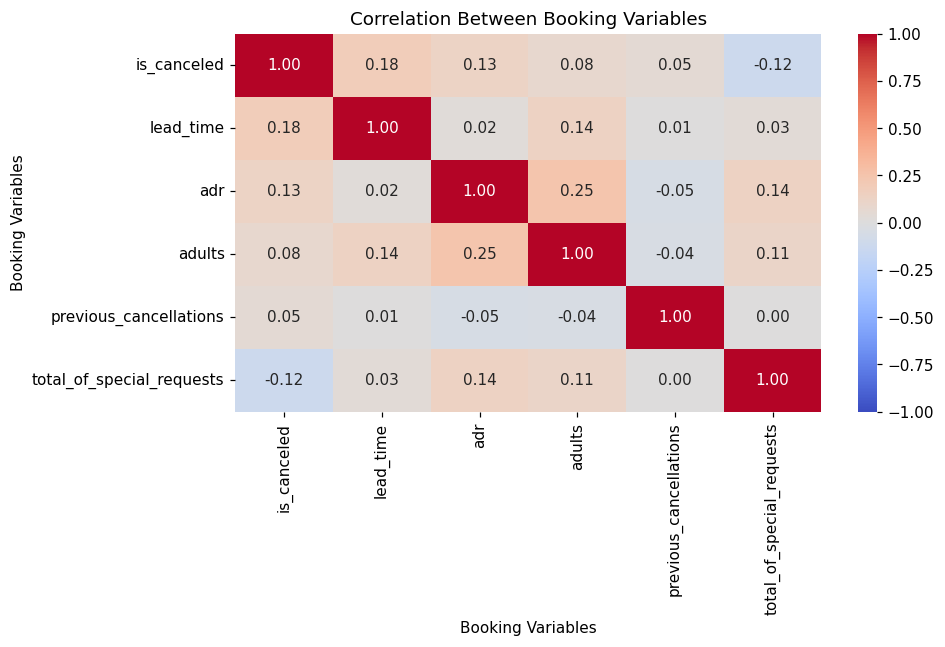

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Correlation Between Booking Variables')
plt.xlabel('Booking Variables')
plt.ylabel('Booking Variables')
plt.tight_layout()
plt.show()

**Observation:** Cancellation has a weak positive correlation with lead time (about 0.18) and a weak negative correlation with special requests (about −0.12). These small associations suggest that neither variable alone explains cancellations. Correlation does not prove cause and effect.

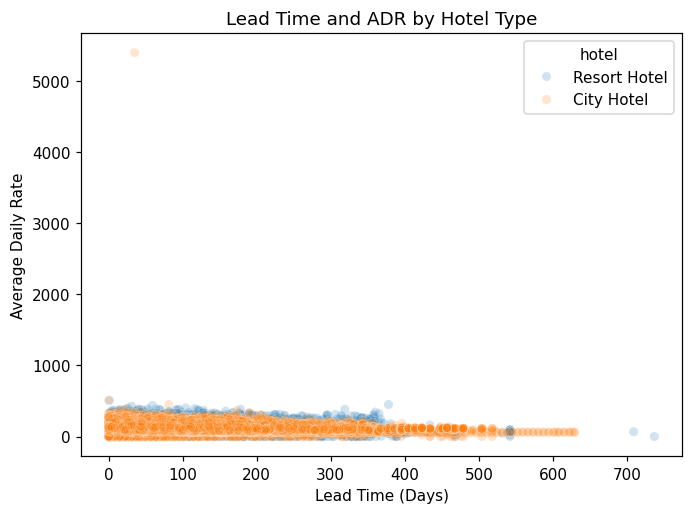

In [ ]:
sns.scatterplot(data=df_clean, x="lead_time", y="adr", hue="hotel", alpha=0.2)
plt.title('Lead Time and ADR by Hotel Type')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Average Daily Rate')
plt.tight_layout()
plt.show()

**Observation:** Adding hotel type allows three variables to be examined together. The extreme ADR still compresses the main cloud of points, so use the hotel-specific medians and correlations alongside this chart.

## 13. Write Key Insights
1. City Hotel has more bookings, so it affects the overall results more.
2. Many bookings were canceled, so bookings do not always become actual stays.
3. City Hotel has a higher cancellation rate than Resort Hotel.
4. A few bookings made far in advance increase the average lead time.
5. Canceled bookings were usually made earlier than bookings that were not canceled.
6. City Hotel has a higher typical daily room rate than Resort Hotel.
7. Guests with more special requests were slightly less likely to cancel.
8. Some room rates are unusual and need checking before making decisions.


## 14. Final Conclusion
City Hotel has more bookings, higher room rates, and a higher cancellation rate than Resort Hotel. Canceled bookings were usually made further in advance.

Duplicate rows were removed, and missing values were filled. Unusual room rates were marked for review.

This dataset can help us understand booking patterns and build a future model to predict cancellations.

The final cleaned DataFrame is `df_clean`.

In [ ]:
print("Final rows and columns:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())
print("Remaining identical rows:", df_clean.duplicated().sum())
df_clean.head()

Final rows and columns: (87396, 34)
Remaining missing values: 0
Remaining identical rows: 0


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,adr_needs_review,adr_outlier
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,Unknown,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01,False,False
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,Unknown,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01,False,False
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,Unknown,Unknown,0,Transient,75.0,0,0,Check-Out,2015-07-02,False,False
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,Unknown,0,Transient,75.0,0,0,Check-Out,2015-07-02,False,False
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,Unknown,0,Transient,98.0,0,1,Check-Out,2015-07-03,False,False
